# 7.4 Cross-Source — Polls & Coverage

**Input:** Newspapers, Polymarket, Polls  
**Output:** Poll movements × media coverage and sentiment

<!-- toc -->
## Contents
  - [Setup](#setup)
- [5. Polls × Newspaper Coverage & Sentiment](#5-polls-newspaper-coverage-sentiment)


## Setup

In [1]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

import house_style as _hs
importlib.reload(_hs)  # force reload — voorkomt stale __pycache__ versie

from house_style import (
    apply_style,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    PALETTE,
    EVENTS,
    add_events, event_legend_handles,
    C_VIX, C_SP500,
    C_FEAR, C_ANGER, C_TRUST, C_DISGUST, C_SADNESS, C_JOY, C_ANTICIPATION,
    BLUESKY_BLUE, REDDIT_ORG,
)
apply_style()



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BRONZE = Path('../../Data/1_Bronze')
SILVER = Path('../../Data/2_Silver')

# ── Colour aliases ─────────────────────────────────────────────────────────
C_TRUMP  = REPUBLICAN
C_HARRIS = DEMOCRAT
C_DEM    = DEMOCRAT
C_REP    = REPUBLICAN
C_CEN    = NEUTRAL
C_MARKET = '#2ec4b6'
C_POLL   = '#9b5de5'

EVENT_DATES = [pd.Timestamp(date) for _, date, _ in EVENTS]

In [2]:
# ── Newspaper features ────────────────────────────────────────────────────────────
nlp  = pd.read_csv(SILVER / 'Newspapers/nlp_features_newspapers.csv',  parse_dates=['date'])
sent = pd.read_csv(SILVER / 'Newspapers/sentiment_features_newspapers.csv', parse_dates=['date'])

news = nlp.merge(sent, on='date', how='outer').sort_values('date').reset_index(drop=True)

# ── MediaCloud article-level → daily coverage metrics ────────────────────────
mc_raw = pd.read_csv(SILVER / 'Newspapers/mediacloud_articles_clean.csv', parse_dates=['date'])
mc_raw['mentions_trump']  = mc_raw['title_clean'].str.contains(r'\btrump\b',  case=False, na=False)
mc_raw['mentions_harris'] = mc_raw['title_clean'].str.contains(r'\bharris\b', case=False, na=False)

mc = (mc_raw.groupby('date')
     .agg(
         total_coverage   = ('title_clean', 'count'),
         n_trump_total    = ('mentions_trump',  'sum'),
         n_harris_total   = ('mentions_harris', 'sum'),
     )
     .reset_index())

denom = (mc['n_trump_total'] + mc['n_harris_total']).replace(0, float('nan'))
mc['trump_share']      = mc['n_trump_total'] / denom
mc['total_coverage_7d'] = mc['total_coverage'].rolling(7, min_periods=3).mean()
mc['trump_share_7d']    = mc['trump_share'].rolling(7,    min_periods=3).mean()

news = news.merge(mc, on='date', how='left')
print(f'Newspaper features : {news.shape}  ({news["date"].min().date()} → {news["date"].max().date()})')

Newspaper features : (118, 94)  (2024-07-05 → 2024-11-04)


In [3]:
# ── Polymarket odds ───────────────────────────────────────────────────────────────
poly = pd.read_csv(BRONZE / 'polymarket/polymarket_win_probabilities.csv',
                    parse_dates=['date'])
poly.columns = ['date', 'trump_odds', 'harris_odds']
poly = poly.sort_values('date').reset_index(drop=True)
print(f'Polymarket         : {poly.shape}  ({poly["date"].min().date()} → {poly["date"].max().date()})')
poly.head(3)

Polymarket         : (128, 3)  (2024-07-01 → 2024-11-05)


,date,trump_odds,harris_odds
0,2024-07-01,66.0,4.45
1,2024-07-02,65.0,9.65
2,2024-07-03,61.5,15.50


In [4]:
# ── Wikipedia polls → 7-day rolling average margin ─────────────────────────
polls_raw = pd.read_csv(BRONZE / 'polls/wikipedia_polls.csv')

# Parse numeric Trump/Harris support
for col in ['Trump', 'Harris']:
    polls_raw[col] = (
        polls_raw[col]
        .astype(str)
        .str.extract(r'([\d.]+)')[0]
        .astype(float)
    )

polls_raw['Date'] = pd.to_datetime(polls_raw['Date'], errors='coerce')
polls_raw = polls_raw.dropna(subset=['Date', 'Trump', 'Harris'])
polls_raw['margin'] = polls_raw['Trump'] - polls_raw['Harris']   # positive = Trump leads

# Daily average (multiple polls on same day)
daily_polls = (
    polls_raw.groupby('Date')[['Trump', 'Harris', 'margin']]
    .mean()
    .reset_index()
    .rename(columns={'Date': 'date', 'Trump': 'poll_trump', 'Harris': 'poll_harris'})
)

# Interpolate to full daily index, then smooth with 7-day rolling mean
date_idx = pd.date_range(daily_polls['date'].min(), daily_polls['date'].max(), freq='D')
daily_polls = (
    daily_polls.set_index('date')
    .reindex(date_idx)
    .interpolate('linear')
    .reset_index()
    .rename(columns={'index': 'date'})
)
daily_polls['poll_trump_7d']   = daily_polls['poll_trump'].rolling(7,  min_periods=1).mean()
daily_polls['poll_harris_7d']  = daily_polls['poll_harris'].rolling(7, min_periods=1).mean()
daily_polls['poll_margin_7d']  = daily_polls['margin'].rolling(7,      min_periods=1).mean()

print(f'Polls (daily interp): {daily_polls.shape}  ({daily_polls["date"].min().date()} → {daily_polls["date"].max().date()})')

Polls (daily interp): (134, 7)  (2024-06-24 → 2024-11-04)


In [5]:
# ── Financial market data ──────────────────────────────────────────────────────────
fin = pd.read_csv(BRONZE / 'financials/market.csv', parse_dates=['Date'])
fin = fin.rename(columns={'Date': 'date'})
fin = fin.sort_values('date').reset_index(drop=True)
print(f'Financials         : {fin.shape}  ({fin["date"].min().date()} → {fin["date"].max().date()})')

Financials         : (108, 6)  (2024-06-03 → 2024-11-04)


In [6]:
# ── Google Trends ──────────────────────────────────
gt = pd.read_csv(BRONZE / 'google_trends/trends_daily_stitched.csv', parse_dates=['date'])
gt = gt.sort_values('date').reset_index(drop=True)

gt = gt.rename(columns={
    'trump':         'gt_trump',
    'kamala':        'gt_kamala',
    'biden':         'gt_biden',
    'elon musk':     'gt_elon',
    'election 2024': 'gt_election',
    'vote':          'gt_vote',
    'conspiracy':    'gt_conspiracy',
    'walz':          'gt_walz',
    'vance':         'gt_vance',
    'campaign':      'gt_campaign',
})

gt['gt_trump_share']       = gt['gt_trump'] / (gt['gt_trump'] + gt['gt_kamala']).replace(0, np.nan)
gt['gt_election_interest'] = gt['gt_election']

print(f'Google Trends      : {gt.shape}  ({gt["date"].min().date()} → {gt["date"].max().date()})')
gt.head(3)


Google Trends      : (123, 8)  (2024-07-05 → 2024-11-04)


,date,gt_trump,gt_kamala,gt_vance,gt_walz,gt_election,gt_trump_share,gt_election_interest
0,2024-07-05,3.0,1.0,0.0,0.0,0.0,0.75,0.0
1,2024-07-06,3.0,0.0,0.0,0.0,0.0,1.00,0.0
2,2024-07-07,2.0,0.0,0.0,0.0,0.0,1.00,0.0


In [7]:
# ── Merge all sources on date ────────────────────────────────────────────────
df = (
    news
    .merge(poly,        on='date', how='left')
    .merge(daily_polls, on='date', how='left')
    .merge(fin,         on='date', how='left')
    .merge(gt,          on='date', how='left')
)
df = df.sort_values('date').reset_index(drop=True)

print(f'Master frame : {df.shape}')
print(f'Date range   : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Missing Polymarket   : {df["trump_odds"].isna().sum()} days')
print(f'Missing Financials   : {df["SP500"].isna().sum()} days (weekends/holidays)')
print(f'Missing Google Trends: {df["gt_trump"].isna().sum()} days')


Master frame : (118, 114)
Date range   : 2024-07-05 → 2024-11-04
Missing Polymarket   : 0 days
Missing Financials   : 37 days (weekends/holidays)
Missing Google Trends: 0 days


In [8]:
import matplotlib.lines as mlines

# ── Event helpers ──────────────────────────────────────────────────────────────
# EVENTS format: [(label, date_str, color), ...] imported from house_style
def add_events(ax, events=None, alpha=0.7):
    """Draw a coloured dashed vertical line for each event. No text on the plot."""
    if events is None:
        events = EVENTS
    for lbl, date_str, color in events:
        ax.axvline(pd.Timestamp(date_str), color=color,
                   linestyle='--', linewidth=1.3, alpha=alpha, zorder=3)

def event_legend(fig, ncol=3):
    """Place a coloured event legend centred at the bottom of fig."""
    handles = [
        mlines.Line2D([], [], color=c, linestyle='--', linewidth=2.5, label=lbl)
        for lbl, _, c in EVENTS
    ]
    fig.legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=ncol,
        facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
        fontsize=9, framealpha=0.95, borderpad=0.8,
    )

def fmt_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')

def style_twin(ax2, ylabel=None, ylabel_color=TEXT_MUTED):
    """Apply dark-theme styling to a twinx axis."""
    ax2.set_facecolor(BG_PANEL)
    for sp in ax2.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
    ax2.tick_params(colors=TEXT_MUTED, labelsize=9)
    if ylabel:
        ax2.set_ylabel(ylabel, color=ylabel_color, fontsize=10)
    ax2.yaxis.label.set_color(ylabel_color)


# 5. Polls × Newspaper Coverage & Sentiment


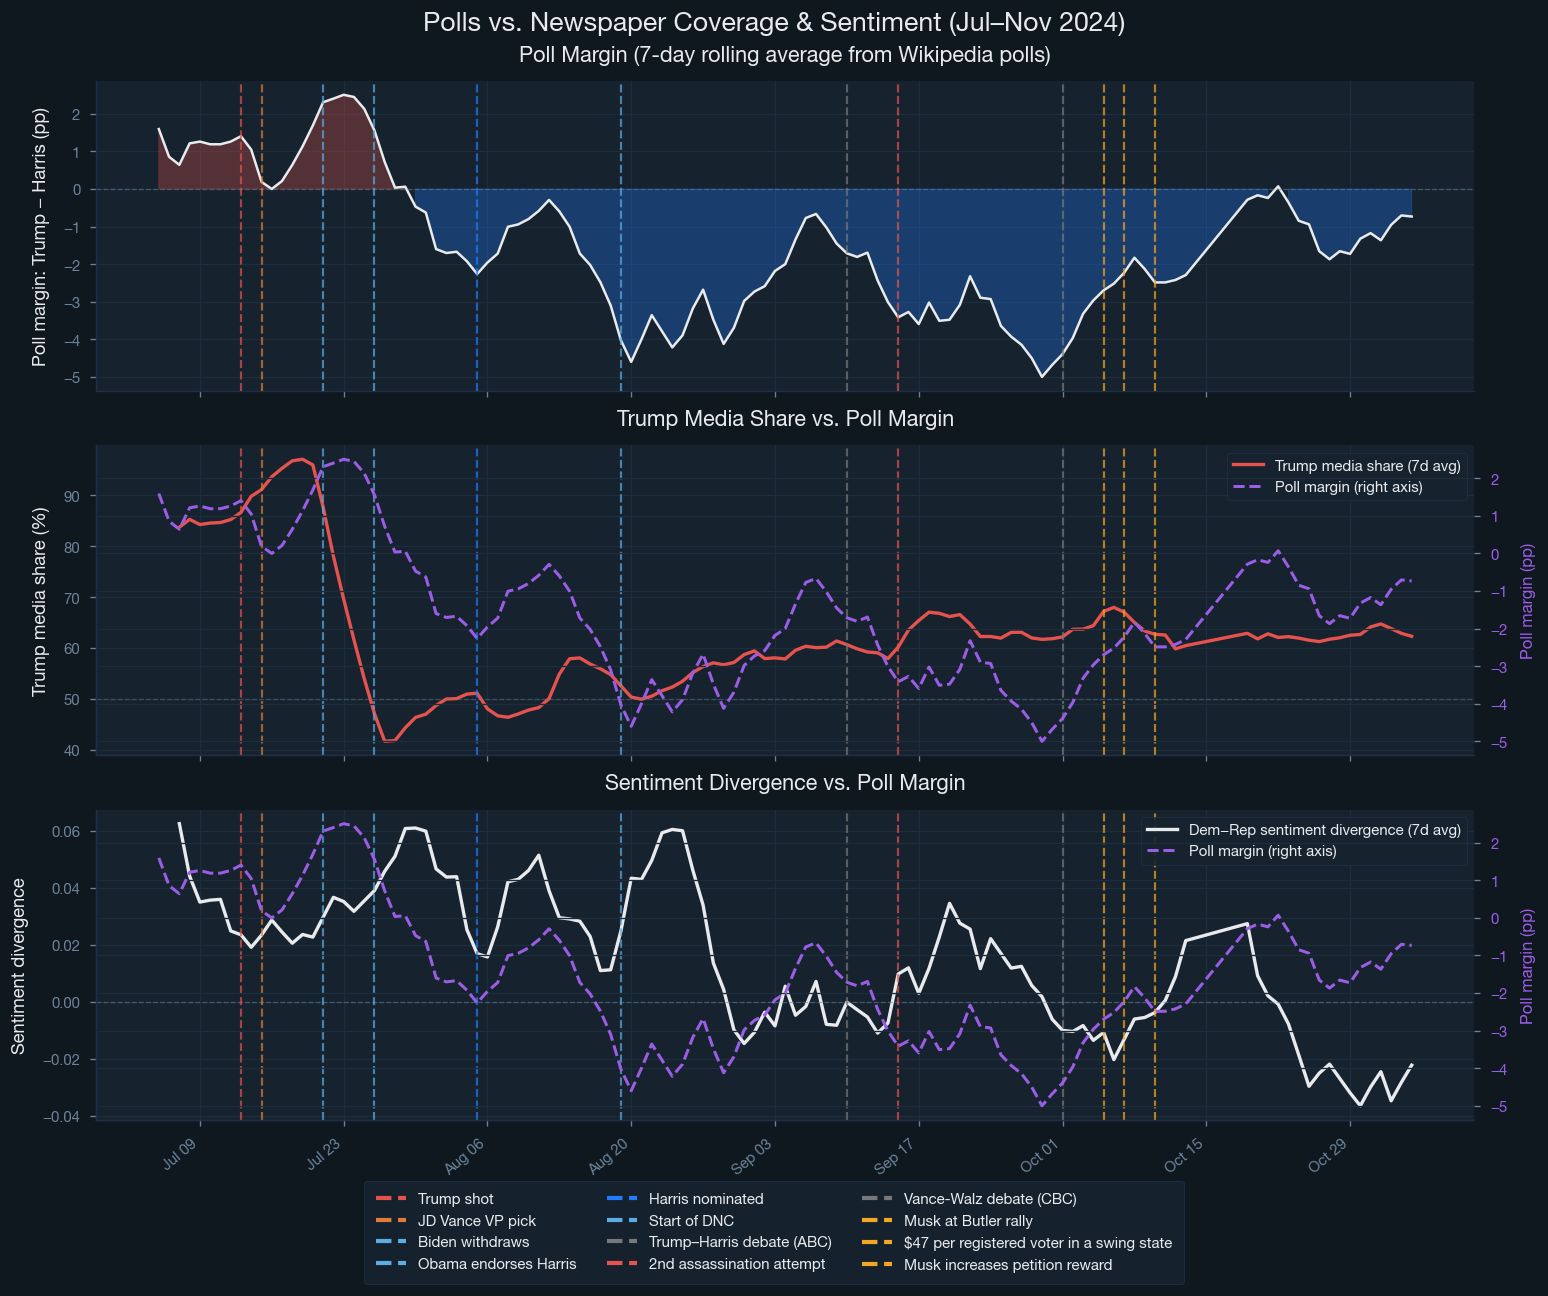

In [10]:
# ── Derived columns ──────────────────────────────────────────────────────
df['sent_divergence'] = df['vader_compound_mean_dem'] - df['vader_compound_mean_rep']
df['sent_div_7d']     = df['sent_divergence'].rolling(7, min_periods=3).mean()
df['fear_avg']  = df[['nrc_fear_dem',  'nrc_fear_rep',  'nrc_fear_cen']].mean(axis=1)
df['anger_avg'] = df[['nrc_anger_dem', 'nrc_anger_rep', 'nrc_anger_cen']].mean(axis=1)
df['trust_avg'] = df[['nrc_trust_dem', 'nrc_trust_rep', 'nrc_trust_cen']].mean(axis=1)
df['antic_avg'] = df[['nrc_anticipation_dem', 'nrc_anticipation_rep', 'nrc_anticipation_cen']].mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

# ─ Panel 1: Poll margin ───────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(df['date'], df['poll_margin_7d'], 0,
                where=df['poll_margin_7d'] >= 0, alpha=0.3, color=C_TRUMP)
ax.fill_between(df['date'], df['poll_margin_7d'], 0,
                where=df['poll_margin_7d'] < 0,  alpha=0.3, color=C_HARRIS)
ax.plot(df['date'], df['poll_margin_7d'], color=TEXT_PRIMARY, lw=1.5)
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Poll margin: Trump − Harris (pp)')
ax.set_title('Poll Margin (7-day rolling average from Wikipedia polls)')
fmt_xaxis(ax)

# ─ Panel 2: Trump media share vs poll margin ──────────────────────────────
ax1 = axes[1]; ax2 = ax1.twinx()
ax1.plot(df['date'], df['trump_share_7d'] * 100, color=C_TRUMP, lw=2,
         label='Trump media share (7d avg)')
ax1.axhline(50, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.4)
ax2.plot(df['date'], df['poll_margin_7d'], color=C_POLL, lw=1.8, ls='--',
         label='Poll margin (right axis)')
ax1.set_ylabel('Trump media share (%)')
style_twin(ax2, ylabel='Poll margin (pp)', ylabel_color=C_POLL)
ax2.tick_params(axis='y', labelcolor=C_POLL)
ax1.set_title('Trump Media Share vs. Poll Margin')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
fmt_xaxis(ax1)

# ─ Panel 3: Sentiment divergence vs poll margin ───────────────────────────
ax1 = axes[2]; ax2 = ax1.twinx()
ax1.plot(df['date'], df['sent_div_7d'], color=TEXT_PRIMARY, lw=2,
         label='Dem−Rep sentiment divergence (7d avg)')
ax1.axhline(0, color=TEXT_MUTED, lw=0.8, ls='--', alpha=0.5)
ax2.plot(df['date'], df['poll_margin_7d'], color=C_POLL, lw=1.8, ls='--',
         label='Poll margin (right axis)')
ax1.set_ylabel('Sentiment divergence')
style_twin(ax2, ylabel='Poll margin (pp)', ylabel_color=C_POLL)
ax2.tick_params(axis='y', labelcolor=C_POLL)
ax1.set_title('Sentiment Divergence vs. Poll Margin')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
fmt_xaxis(ax1)

for ax in axes:
    add_events(ax)

fig.suptitle('Polls vs. Newspaper Coverage & Sentiment (Jul–Nov 2024)')
plt.tight_layout()
fig.subplots_adjust(bottom=0.14)
event_legend(fig)
plt.show()
